# **CNN - Classificação de Imagens de Pacientes com Pneumonia**<font size=3>

### **1. Importação e análise dos dados:**<font size=3>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization

In [2]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [3]:
labels = ['NORMAL', 'PNEUMONIA']

def mount_dataset(dir):
  x = []
  y = []

  for label in labels:
    caminho = dir + '/' + label + '/'
    classe = labels.index(label)

    for img in os.listdir(caminho):
      try:
        img = Image.open((caminho + img)).convert('L')
        img_resized = img.resize((150, 150))
        img_array = np.array(img_resized)

        x.append(img_array)
        y.append(classe)

      except Exception as e:
        print(e)

  x = np.array(x)
  y = np.array(y)
  x = x.reshape(-1, 150, 150, 1)

  return x, y

In [4]:
x_train_inicial, y_train_inicial = mount_dataset('/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train')
x_test_inicial, y_test_inicial = mount_dataset('/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test')

cannot identify image file '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/.DS_Store'
cannot identify image file '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA/.DS_Store'


In [5]:
state = np.random.default_rng(12)

indices_treino = state.permutation(len(x_train_inicial))
x_train = x_train_inicial[indices_treino]
y_train = y_train_inicial[indices_treino]

indices_teste = state.permutation(len(x_test_inicial))
x_test = x_test_inicial[indices_teste]
y_test = y_test_inicial[indices_teste]

In [6]:
print(f"X-train:{x_train.shape}, y-train:{y_train.shape}")
print(f"X-test:{x_test.shape}, y-test:{y_test.shape}")

X-train:(5216, 150, 150, 1), y-train:(5216,)
X-test:(624, 150, 150, 1), y-test:(624,)


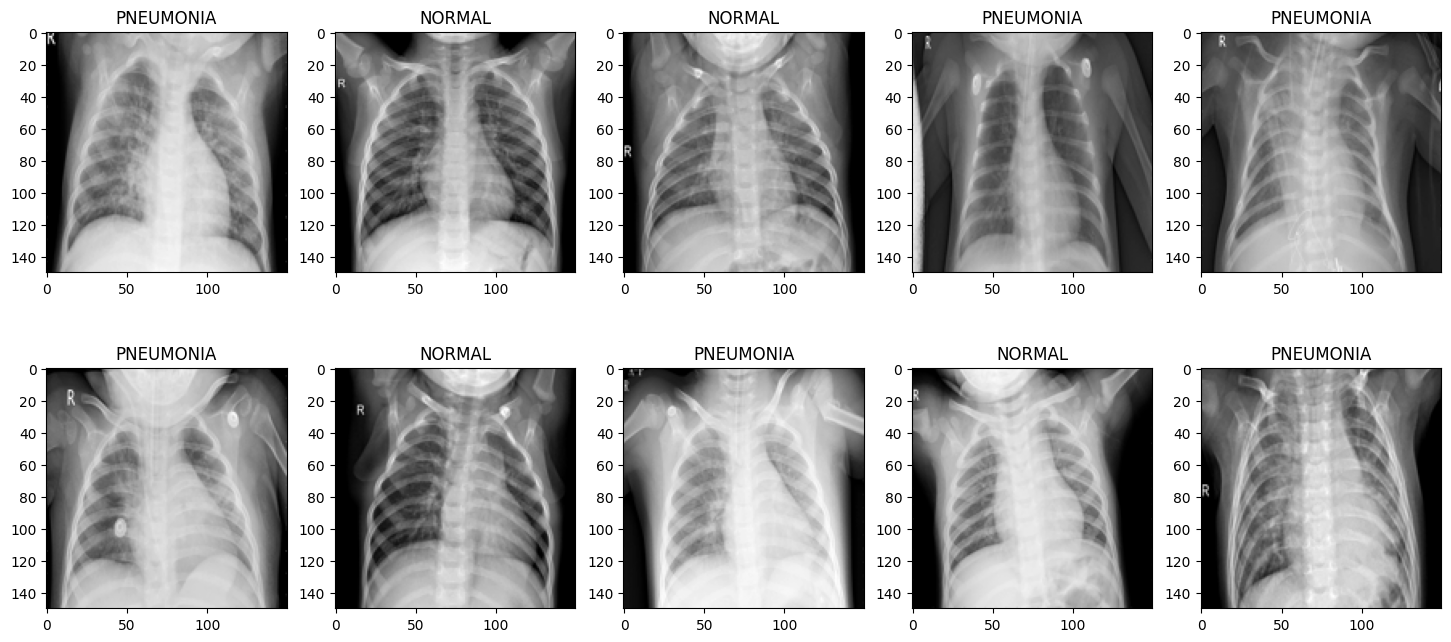

In [7]:
plt.figure(figsize=(18, 8))

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)

    img = x_train[i]
    plt.imshow(img, cmap='gray')

    if y_train[i] == 1:
        plt.title("PNEUMONIA")
    else:
        plt.title("NORMAL")

A função denominada "mount_dataset" foi criada com o intuito de realizar a leitura dos caminhos que indicam a localização das imagens e montar os conjuntos de dados que serão realizadas, sendo o treino e de teste. As imagens foram convertidas para a escala de cinza e reduzidas para o tamanho de 150x150 a fim de facilitar o uso delas. Além disso, foi aplicado um "reshape" para que já estejam adaptadas ao formato desejado no modelo que será criado.

Após a montagem dos conjuntos, as imagens foram embaralhadas e verificou-se uma quantidade de 5216 amostras presentes na base de treino, enquanto o conjunto de teste possui a quantidade reduzida de 624. Para obter uma visão de como as imagens usadas se parecem, foi gerado um pequeno plot das 10 primeiras amostras do conjunto de treino

### **2. Pré-processamento:**<font size=3>

In [8]:
classes_train, n_amostras_train = np.unique(y_train, return_counts=True)
classes_test, n_amostras_test = np.unique(y_test, return_counts=True)

print("As classes existentes são 0 (Normal) e 1 (Pneumonia).")
print(f"\nA proporção das classes no treino é {n_amostras_train}.")
print(f"A proporção das classes no teste é {n_amostras_test}.")

As classes existentes são 0 (Normal) e 1 (Pneumonia).

A proporção das classes no treino é [1341 3875].
A proporção das classes no teste é [234 390].


In [9]:
x_train.min(), x_train.max()

(np.uint8(0), np.uint8(255))

In [10]:
x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

N_train, height, width, channels = x_train.shape
N_test, _, _, _ = x_test.shape

Max = x_train.max()

x_train /= Max
x_test /= Max

Diferente da MLP, não é necessário realizar o achatamento das imagens como uma das primeiras etapas, pois as informações espaciais e os padrões existentes não conseguiriam ser identificados, logo, o pré-processamento foi composto apenas pelas seguintes etapas:
*   Conversão das imagens para o tipo float32;
*   Normalização dos pixels para deixá-los com valores entre 0 e 1;

### **3. Modelagem e compilação:**<font size=3>

In [11]:
model = Sequential()

model.add(Conv2D(32, (3, 3), padding='same', activation = 'relu', input_shape = (150, 150, 1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2)))

model.add(Conv2D(64, (3, 3), padding='same', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.1))

model.add(Conv2D(128, (3, 3), padding='same', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(256, (3, 3), padding='same', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(units = 128, activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(units = 1, activation = 'sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,044,225 (11.61 MB)

 Trainable params: 3,043,265 (11.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
model.compile(optimizer="Adam", loss="binary_crossentropy", metrics=['acc'])

Uma Rede Neural Convolucional (CNN) foi utilizada, compilada usando o otimizador Adam, a função de perda Binary Cross Entropy, além da métrica Accuracy.

A afinação do modelo foi realizada testando-o com diferentes parâmetros descritos posteriormente, no entanto, a configuração final que apresentou os melhores resultados é a apresentada acima no sumário.


### **4. Treinamento validativo:**<font size=3>

In [13]:
n_epochs = 12
tamanho_batch = 32

Epoch 1/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - acc: 0.8955 - loss: 0.5790 - val_acc: 0.7548 - val_loss: 13.3592
Epoch 2/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - acc: 0.9494 - loss: 0.1288 - val_acc: 0.7548 - val_loss: 10.3865
Epoch 3/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - acc: 0.9674 - loss: 0.0984 - val_acc: 0.7548 - val_loss: 5.6378
Epoch 4/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - acc: 0.9636 - loss: 0.0931 - val_acc: 0.8103 - val_loss: 1.1451
Epoch 5/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - acc: 0.9681 - loss: 0.0797 - val_acc: 0.9502 - val_loss: 0.1533
Epoch 6/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - acc: 0.9722 - loss: 0.0686 - val_acc: 0.9761 - val_loss: 0.0655
Epoch 7/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - acc: 0.9760 - loss: 0.0671 - val_acc: 0.9243 - val_loss: 0.5274
Epoch 8/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - acc: 0.9808 - loss: 0.0483 - val_acc: 0.9741 - val_loss: 0.0882
Epoch 9/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 3

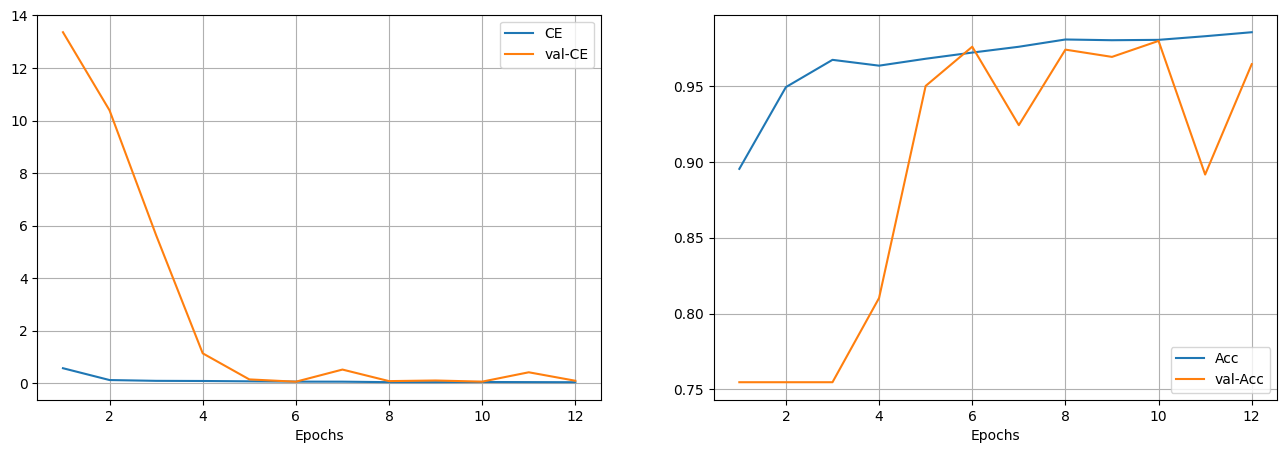

In [ ]:
final_training = False

if not final_training:
    report = model.fit(x=x_train, y=y_train, validation_split=0.2,
                       epochs=n_epochs, batch_size=tamanho_batch)

    loss = report.history['loss']
    acc = report.history['acc']

    val_loss = report.history['val_loss']
    val_acc = report.history['val_acc']

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    ax[0].plot(epochs, loss, label='CE')
    ax[0].plot(epochs, val_loss, label='val-CE')

    ax[1].plot(epochs, acc, label='Acc')
    ax[1].plot(epochs, val_acc, label='val-Acc')

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].legend()
        ax[i].grid()

    plt.show()

O número de épocas foi aumentado para 12 e o tamanho de cada lote manteve-se como 32. Portanto, a imagem gerada acima novamente representa a comparação dos resultados obtidos entre o treino e a validação, criada a partir de 20% das amostras de treino. Observando ambos os gráficos, constata-se que a linha do tempo entre os dois conjuntos aproximou-se com o decorrer das épocas, e ao final com os valores de acurácia, temos apenas uma pequena diferença, indicando que não existe overfitting nesse modelo.

### **5. Treinamento final:**<font size=3>

Epoch 1/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - acc: 0.9317 - loss: 0.3426
Epoch 2/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - acc: 0.9622 - loss: 0.1005
Epoch 3/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.9655 - loss: 0.0941
Epoch 4/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.9720 - loss: 0.0832
Epoch 5/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.9739 - loss: 0.0766
Epoch 6/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - acc: 0.9793 - loss: 0.0562
Epoch 7/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.9808 - loss: 0.0572
Epoch 8/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - acc: 0.9856 - loss: 0.0418
Epoch 9/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - acc: 0.9803 - loss: 0.0519
Epoch 10/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - acc: 0.9866 - loss: 0.0398
Epoch 11/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - acc: 0.9868 - loss: 0.0393
Epoch 12/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.9885 - loss: 0.0293


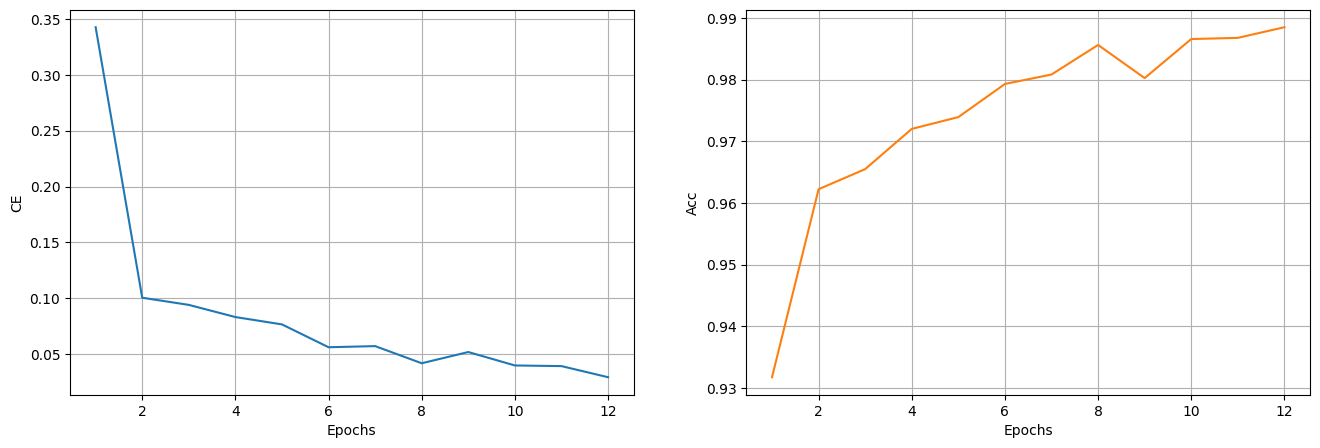

In [14]:
final_training = True

if final_training:
    report_final = model.fit(x=x_train, y=y_train, epochs=n_epochs, batch_size=tamanho_batch)

    loss = report_final.history['loss']
    acc = report_final.history['acc']

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    ax[0].plot(epochs, loss, c='tab:blue')
    ax[1].plot(epochs, acc, c='tab:orange')

    ax[0].set_ylabel('CE')
    ax[1].set_ylabel('Acc')

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].grid()

    plt.show()

No treinamento final do modelo, obtemos um valor de perda com 0.0274 e acurácia atingindo 0.991, logo, é possível concluir que o modelo criado desempenhou bem e agora poderíamos testá-lo com o conjunto de teste para avaliá-lo com diferentes dados.

### **6. Avaliação do modelo:**<font size=3>

In [15]:
if final_training:
    ce, acc = model.evaluate(x=x_test, y=y_test, batch_size=tamanho_batch)

    print(f"\nCE = {ce:.4f}, acc = {acc:.4f}\n")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7548 - loss: 1.6332

CE = 1.6332, acc = 0.7548



In [16]:
if final_training:

    y_pred_prob = model.predict(x_test)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    print("\ny-pred | y-test")
    print("---------------")

    for p, y in zip(y_pred[:10], y_test[:10]):
      print(f" {p}  |  {y}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step

y-pred | y-test
---------------
 [1]  |  1
 [1]  |  1
 [1]  |  0
 [1]  |  0
 [1]  |  1
 [1]  |  1
 [1]  |  1
 [1]  |  1
 [1]  |  1
 [1]  |  1


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

              precision    recall  f1-score   support

      NORMAL       0.99      0.35      0.52       234
   PNEUMONIA       0.72      1.00      0.84       390

    accuracy                           0.75       624
   macro avg       0.85      0.67      0.68       624
weighted avg       0.82      0.75      0.72       624



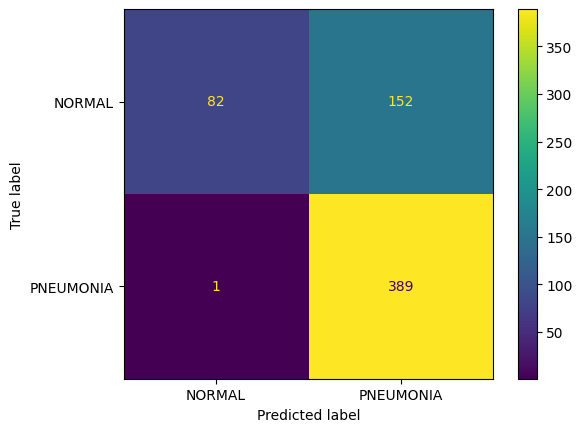

In [18]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NORMAL', 'PNEUMONIA'])
disp.plot()
plt.show()

Avaliando o modelo com os dados de teste, obtemos um valor de perda com 1.770 e acurácia atingindo 0.769. Sendo assim, conclue-se que o modelo ainda possui um bom valor de acurácia, porém, ele tem uma incerteza muito alta nas suas predições.

Um relatório completo e uma matriz de confusão foram criados para investigar o que pode ter acontecido com o modelo, e ao observar os baixos valores de revocação e F1-Score para a classe NORMAL, além da elevada quantidade de falsos positivos, é possível concluir que o modelo não conseguiu aprender os padrões e generalizar o seu conhecimento da classe de pacientes sem pneumonia para novos dados. Portanto, é possível apontar que um dos principais culpados do mau desempenho seria o desbalanceamento entre as classes, resultando em um modelo abaixo do esperado quee não deve ser usado para auxílio médico devido a sua ineficácia em classificar corretamente os pacientes.